Complex Functions:

In [1]:
from torch.nn.functional import relu, max_pool2d, max_unpool2d, dropout, dropout2d


def complex_relu(input_r, input_i):
    return relu(input_r), relu(input_i)


def complex_max_pool2d(input_r, input_i, kernel_size, stride=None, padding=0,
                       dilation=1, ceil_mode=False, return_indices=False):
    return max_pool2d(input_r, kernel_size, stride, padding, dilation,
                      ceil_mode, return_indices), \
           max_pool2d(input_i, kernel_size, stride, padding, dilation,
                      ceil_mode, return_indices)

#10181530
def complex_max_unpool2d(input_r, input_i, idx_r, idx_i, kernel_size, stride=None,
                         padding=0, output_size=None):
    return max_unpool2d(input_r, idx_r, kernel_size, stride, padding, output_size), \
           max_unpool2d(input_i, idx_i, kernel_size, stride, padding, output_size)

def complex_dropout(input_r, input_i, p=0.5, training=True, inplace=False):
    return dropout(input_r, p, training, inplace), \
           dropout(input_i, p, training, inplace)


def complex_dropout2d(input_r, input_i, p=0.5, training=True, inplace=False):
    return dropout2d(input_r, p, training, inplace), \
           dropout2d(input_i, p, training, inplace)

Complex Layers:

In [2]:
import torch
from torch.nn import Module, Parameter, init, Sequential
from torch.nn import Conv2d, Linear, BatchNorm1d, BatchNorm2d
from torch.nn import ConvTranspose2d



class ComplexSequential(Sequential):
    def forward(self, input_r, input_t):
        for module in self._modules.values():
            input_r, input_t = module(input_r, input_t)
        return input_r, input_t


class ComplexDropout(Module):
    def __init__(self, p=0.5, inplace=False):
        super(ComplexDropout, self).__init__()
        self.p = p
        self.inplace = inplace

    def forward(self, input_r, input_i):
        return complex_dropout(input_r, input_i, self.p, self.inplace)


class ComplexDropout2d(Module):
    def __init__(self, p=0.5, inplace=False):
        super(ComplexDropout2d, self).__init__()
        self.p = p
        self.inplace = inplace

    def forward(self, input_r, input_i):
        return complex_dropout2d(input_r, input_i, self.p, self.inplace)


class ComplexMaxPool2d(Module):

    def __init__(self, kernel_size, stride=None, padding=0,
                 dilation=1, return_indices=False, ceil_mode=False):
        super(ComplexMaxPool2d, self).__init__()
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.dilation = dilation
        self.ceil_mode = ceil_mode
        self.return_indices = return_indices

    def forward(self, input_r, input_i):
        return complex_max_pool2d(input_r, input_i, kernel_size=self.kernel_size,
                                  stride=self.stride, padding=self.padding,
                                  dilation=self.dilation, ceil_mode=self.ceil_mode,
                                  return_indices=self.return_indices)

#10181817
class ComplexMaxUnPool2d(Module):

    def __init__(self, indices, kernel_size, stride=None,
                 padding=0, output_size=None):
        super(ComplexMaxUnPool2d, self).__init__()
        self.indices = indices
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.output_size = output_size

    def forward(self, input_r, input_i):
        return complex_max_unpool2d(input_r, input_i, idx_r, idx_i, kernel_size=self.kernel_size,
                                    stride=self.stride, padding=self.padding,
                                    output_size = self.output_size)


class ComplexReLU(Module):

    def forward(self, input_r, input_i):
        return complex_relu(input_r, input_i)


class ComplexConvTranspose2d(Module):

    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0,
                 output_padding=0, groups=1, bias=True, dilation=1, padding_mode='zeros'):
        super(ComplexConvTranspose2d, self).__init__()

        self.conv_tran_r = ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding,
                                           output_padding, groups, bias, dilation)
        self.conv_tran_i = ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding,
                                           output_padding, groups, bias, dilation)

    def forward(self, input_r, input_i):
        return self.conv_tran_r(input_r) - self.conv_tran_i(input_i), \
               self.conv_tran_r(input_i) + self.conv_tran_i(input_r)


class ComplexConv2d(Module):

    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=0,
                 dilation=1, groups=1, bias=True):
        super(ComplexConv2d, self).__init__()
        self.conv_r = Conv2d(in_channels, out_channels, kernel_size, stride, padding, dilation, groups, bias)
        self.conv_i = Conv2d(in_channels, out_channels, kernel_size, stride, padding, dilation, groups, bias)

    def forward(self, input_r, input_i):
        #       assert(input_r.size() == input_i.size())
        return self.conv_r(input_r) - self.conv_i(input_i), \
               self.conv_r(input_i) + self.conv_i(input_r)


class ComplexLinear(Module):

    def __init__(self, in_features, out_features):
        super(ComplexLinear, self).__init__()
        self.fc_r = Linear(in_features, out_features)
        self.fc_i = Linear(in_features, out_features)

    def forward(self, input_r, input_i):
        return self.fc_r(input_r) - self.fc_i(input_i), \
               self.fc_r(input_i) + self.fc_i(input_r)


class NaiveComplexBatchNorm1d(Module):
    '''
    Naive approach to complex batch norm, perform batch norm independently on real and imaginary part.
    '''

    def __init__(self, num_features, eps=1e-5, momentum=0.1, affine=True, \
                 track_running_stats=True):
        super(NaiveComplexBatchNorm1d, self).__init__()
        self.bn_r = BatchNorm1d(num_features, eps, momentum, affine, track_running_stats)
        self.bn_i = BatchNorm1d(num_features, eps, momentum, affine, track_running_stats)

    def forward(self, input_r, input_i):
        return self.bn_r(input_r), self.bn_i(input_i)


class NaiveComplexBatchNorm2d(Module):
    '''
    Naive approach to complex batch norm, perform batch norm independently on real and imaginary part.
    '''

    def __init__(self, num_features, eps=1e-5, momentum=0.1, affine=True, \
                 track_running_stats=True):
        super(NaiveComplexBatchNorm2d, self).__init__()
        self.bn_r = BatchNorm2d(num_features, eps, momentum, affine, track_running_stats)
        self.bn_i = BatchNorm2d(num_features, eps, momentum, affine, track_running_stats)

    def forward(self, input_r, input_i):
        return self.bn_r(input_r), self.bn_i(input_i)


class NaiveComplexBatchNorm1d(Module):
    '''
    Naive approach to complex batch norm, perform batch norm independently on real and imaginary part.
    '''

    def __init__(self, num_features, eps=1e-5, momentum=0.1, affine=True, \
                 track_running_stats=True):
        super(NaiveComplexBatchNorm1d, self).__init__()
        self.bn_r = BatchNorm1d(num_features, eps, momentum, affine, track_running_stats)
        self.bn_i = BatchNorm1d(num_features, eps, momentum, affine, track_running_stats)

    def forward(self, input_r, input_i):
        return self.bn_r(input_r), self.bn_i(input_i)


class _ComplexBatchNorm(Module):

    def __init__(self, num_features, eps=1e-5, momentum=0.1, affine=True,
                 track_running_stats=True):
        super(_ComplexBatchNorm, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum
        self.affine = affine
        self.track_running_stats = track_running_stats
        if self.affine:
            self.weight = Parameter(torch.Tensor(num_features, 3))
            self.bias = Parameter(torch.Tensor(num_features, 2))
        else:
            self.register_parameter('weight', None)
            self.register_parameter('bias', None)
        if self.track_running_stats:
            self.register_buffer('running_mean', torch.zeros(num_features, 2))
            self.register_buffer('running_covar', torch.zeros(num_features, 3))
            self.running_covar[:, 0] = 1.4142135623730951
            self.running_covar[:, 1] = 1.4142135623730951
            self.register_buffer('num_batches_tracked', torch.tensor(0, dtype=torch.long))
        else:
            self.register_parameter('running_mean', None)
            self.register_parameter('running_covar', None)
            self.register_parameter('num_batches_tracked', None)
        self.reset_parameters()

    def reset_running_stats(self):
        if self.track_running_stats:
            self.running_mean.zero_()
            self.running_covar.zero_()
            self.running_covar[:, 0] = 1.4142135623730951
            self.running_covar[:, 1] = 1.4142135623730951
            self.num_batches_tracked.zero_()

    def reset_parameters(self):
        self.reset_running_stats()
        if self.affine:
            init.constant_(self.weight[:, :2], 1.4142135623730951)
            init.zeros_(self.weight[:, 2])
            init.zeros_(self.bias)


class ComplexBatchNorm2d(_ComplexBatchNorm):

    def forward(self, input_r, input_i):
        assert (input_r.size() == input_i.size())
        assert (len(input_r.shape) == 4)
        exponential_average_factor = 0.0

        if self.training and self.track_running_stats:
            if self.num_batches_tracked is not None:
                self.num_batches_tracked += 1
                if self.momentum is None:  # use cumulative moving average
                    exponential_average_factor = 1.0 / float(self.num_batches_tracked)
                else:  # use exponential moving average
                    exponential_average_factor = self.momentum

        if self.training:

            # calculate mean of real and imaginary part
            mean_r = input_r.mean([0, 2, 3])
            mean_i = input_i.mean([0, 2, 3])

            mean = torch.stack((mean_r, mean_i), dim=1)

            # update running mean
            with torch.no_grad():
                self.running_mean = exponential_average_factor * mean \
                                    + (1 - exponential_average_factor) * self.running_mean

            input_r = input_r - mean_r[None, :, None, None]
            input_i = input_i - mean_i[None, :, None, None]

            # Elements of the covariance matrix (biased for train)
            n = input_r.numel() / input_r.size(1)
            Crr = 1. / n * input_r.pow(2).sum(dim=[0, 2, 3]) + self.eps
            Cii = 1. / n * input_i.pow(2).sum(dim=[0, 2, 3]) + self.eps
            Cri = (input_r.mul(input_i)).mean(dim=[0, 2, 3])

            with torch.no_grad():
                self.running_covar[:, 0] = exponential_average_factor * Crr * n / (n - 1) \
                                           + (1 - exponential_average_factor) * self.running_covar[:, 0]

                self.running_covar[:, 1] = exponential_average_factor * Cii * n / (n - 1) \
                                           + (1 - exponential_average_factor) * self.running_covar[:, 1]

                self.running_covar[:, 2] = exponential_average_factor * Cri * n / (n - 1) \
                                           + (1 - exponential_average_factor) * self.running_covar[:, 2]

        else:
            mean = self.running_mean
            Crr = self.running_covar[:, 0] + self.eps
            Cii = self.running_covar[:, 1] + self.eps
            Cri = self.running_covar[:, 2]  # +self.eps

            input_r = input_r - mean[None, :, 0, None, None]
            input_i = input_i - mean[None, :, 1, None, None]

        # calculate the inverse square root the covariance matrix
        det = Crr * Cii - Cri.pow(2)
        s = torch.sqrt(det)
        t = torch.sqrt(Cii + Crr + 2 * s)
        inverse_st = 1.0 / (s * t)
        Rrr = (Cii + s) * inverse_st
        Rii = (Crr + s) * inverse_st
        Rri = -Cri * inverse_st

        input_r, input_i = Rrr[None, :, None, None] * input_r + Rri[None, :, None, None] * input_i, \
                           Rii[None, :, None, None] * input_i + Rri[None, :, None, None] * input_r

        if self.affine:
            input_r, input_i = self.weight[None, :, 0, None, None] * input_r + self.weight[None, :, 2, None,
                                                                               None] * input_i + \
                               self.bias[None, :, 0, None, None], \
                               self.weight[None, :, 2, None, None] * input_r + self.weight[None, :, 1, None,
                                                                               None] * input_i + \
                               self.bias[None, :, 1, None, None]

        return input_r, input_i


class ComplexBatchNorm1d(_ComplexBatchNorm):

    def forward(self, input_r, input_i):
        assert (input_r.size() == input_i.size())
        assert (len(input_r.shape) == 2)
        # self._check_input_dim(input)

        exponential_average_factor = 0.0

        if self.training and self.track_running_stats:
            if self.num_batches_tracked is not None:
                self.num_batches_tracked += 1
                if self.momentum is None:  # use cumulative moving average
                    exponential_average_factor = 1.0 / float(self.num_batches_tracked)
                else:  # use exponential moving average
                    exponential_average_factor = self.momentum

        if self.training:

            # calculate mean of real and imaginary part
            mean_r = input_r.mean(dim=0)
            mean_i = input_i.mean(dim=0)
            mean = torch.stack((mean_r, mean_i), dim=1)

            # update running mean
            with torch.no_grad():
                self.running_mean = exponential_average_factor * mean \
                                    + (1 - exponential_average_factor) * self.running_mean

            # zero mean values
            input_r = input_r - mean_r[None, :]
            input_i = input_i - mean_i[None, :]

            # Elements of the covariance matrix (biased for train)
            n = input_r.numel() / input_r.size(1)
            Crr = input_r.var(dim=0, unbiased=False) + self.eps
            Cii = input_i.var(dim=0, unbiased=False) + self.eps
            Cri = (input_r.mul(input_i)).mean(dim=0)

            with torch.no_grad():
                self.running_covar[:, 0] = exponential_average_factor * Crr * n / (n - 1) \
                                           + (1 - exponential_average_factor) * self.running_covar[:, 0]

                self.running_covar[:, 1] = exponential_average_factor * Cii * n / (n - 1) \
                                           + (1 - exponential_average_factor) * self.running_covar[:, 1]

                self.running_covar[:, 2] = exponential_average_factor * Cri * n / (n - 1) \
                                           + (1 - exponential_average_factor) * self.running_covar[:, 2]

        else:
            mean = self.running_mean
            Crr = self.running_covar[:, 0] + self.eps
            Cii = self.running_covar[:, 1] + self.eps
            Cri = self.running_covar[:, 2]
            # zero mean values
            input_r = input_r - mean[None, :, 0]
            input_i = input_i - mean[None, :, 1]

        # calculate the inverse square root the covariance matrix
        det = Crr * Cii - Cri.pow(2)
        s = torch.sqrt(det)
        t = torch.sqrt(Cii + Crr + 2 * s)
        inverse_st = 1.0 / (s * t)
        Rrr = (Cii + s) * inverse_st
        Rii = (Crr + s) * inverse_st
        Rri = -Cri * inverse_st

        input_r, input_i = Rrr[None, :] * input_r + Rri[None, :] * input_i, \
                           Rii[None, :] * input_i + Rri[None, :] * input_r

        if self.affine:
            input_r, input_i = self.weight[None, :, 0] * input_r + self.weight[None, :, 2] * input_i + \
                               self.bias[None, :, 0], \
                               self.weight[None, :, 2] * input_r + self.weight[None, :, 1] * input_i + \
                               self.bias[None, :, 1]

        del Crr, Cri, Cii, Rrr, Rii, Rri, det, s, t
        return input_r, input_i

Configuration:

In [3]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import os.path as osp

qb = 3

k_qb = {3: 3, 4: 5, 5: 5}
k = k_qb[qb]

MODEL_CONFIG = {

    'c1': 30, 'k1': k,

    'c2': 30, 'k2': k,

    'c3': 10, 'k3': k,

    'd1': 96, 'd2': 10
}

TRAIN_CONFIG = {
    'is_train' : False,

    'generate_data' : False,

    'train_size': 160000,

    's_test_size': 8000,

    'e_test_size': 10000,

    'train_set_path': f'/kaggle/input/{qb}qb-train-and-test/rand_sep_train_160k.npy',

    's_test_set_path': f'/kaggle/input/{qb}qb-calibration/rand_sep_cal_8k.npy',

    'e_test_set_path': f'/kaggle/input/{qb}qb-calibration/rand_ent_cal_1k.npy',

    'result_path': 'result.txt',

    'train_config': {  'epoch': 100,
                        'batch_size': 1024,
                        'device': 'cuda:0', },

    'validation_data_config': {'batch_size': 10000,
                               'device': 'cpu', },

}

Tools:

In [4]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import torch
import os
from sklearn.metrics import roc_curve, auc, average_precision_score, f1_score
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from collections import Counter, defaultdict #09191655
import numpy as np #09212249
from sklearn.cluster import KMeans
from scipy.stats import entropy
from sklearn.mixture import GaussianMixture
from matplotlib.colors import ListedColormap

def mkdir(path):
    folder = os.path.exists(path)
    if not folder:
        os.makedirs(path)
        print('Folder have been made!')


def l1_loss(input, target, test=False):
    """ L1 Loss without reduce flag.
    Args:
        input (FloatTensor): Input tensor
        target (FloatTensor): Output tensor
    Returns:
        [FloatTensor]: L1 distance between input and output
    """
    if test:
        return torch.mean(torch.abs(input[0] - target[0]) + torch.abs(input[1] - target[1]), dim=[1, 2, 3], keepdim=False)
    else:
        return torch.mean(torch.abs(input[0] - target[0]) + torch.abs(input[1] - target[1]))


##
def l2_loss_real(input, target, size_average=True):
    """ L2 Loss without reduce flag.

    Args:
        input (FloatTensor): Input tensor
        target (FloatTensor): Output tensor

    Returns:
        [FloatTensor]: L2 distance between input and output
    """
    if size_average:
        return torch.mean(torch.pow((input - target), 2))
    else:
        return torch.pow((input - target), 2)


def l2_loss_complex(input, target, test=False):
    """ L2 Loss without reduce flag.

    Args:
        input (FloatTensor): Input tensor
        target (FloatTensor): Output tensor

    Returns:
        [FloatTensor]: L2 distance between input and output
    """
    if test:
        return torch.mean(torch.pow((input[0] - target[0]), 2) + torch.pow((input[1] - target[1]), 2), dim=1,
                          keepdim=False)
    else:
        return torch.mean(torch.pow((input[0] - target[0]), 2) + torch.pow((input[1] - target[1]), 2))


def roc(labels, scores, number, saveto=None):
    """Compute ROC curve and ROC area for each class"""
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # True/False Positive Rates.
    fpr, tpr, threshold = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    print('AUC: %0.4f' % (roc_auc))
    # Equal Error Rate
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    print('EER: %0.4f' % (eer))
    
    idx = np.argmin(np.abs(fpr - eer)) #09130954
    key_thresh = threshold[idx]
    # print('threshold next 5：', threshold[idx:idx+5]) #09130954
    
    if saveto:
        plt.figure()
        lw = 2
        plt.plot(fpr, tpr, color='darkorange', lw=lw, label='(AUC = %0.4f, EER = %0.4f)' % (roc_auc, eer))

        plt.plot([eer], [1 - eer], marker='o', markersize=5, color="navy")
        plt.plot([0, 1], [1, 0], color='navy', lw=1, linestyle=':')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(loc="lower right")
        plt.savefig(os.path.join(saveto, 'ROC_%d.png' % (number)))
        plt.close()

    return roc_auc, eer, key_thresh

def rank_distr(score, la, rank, m, key_thresh, epoch): #09191417
    pairs = list(zip(score, rank))
    pairs_sorted = sorted(pairs, key=lambda x: x[0])
    sorted_score, sorted_rank = zip(*pairs_sorted)

    #tensor change to list
    sorted_score = [t.item() for t in sorted_score]
    # sorted_rank = [t.item() for t in sorted_rank]

    key_idx = np.argmin(np.abs(sorted_score - key_thresh))
    print('key threshold:', key_thresh)
    print('key index:', key_idx)

    ideal_sep_loss = sorted_score[:key_idx]
    ideal_sep_rank = sorted_rank[:key_idx]

    ideal_ent_loss = sorted_score[key_idx:]
    ideal_ent_rank = sorted_rank[key_idx:]
    
    print('----------------------⬇️-----------------------')
    #09162038 #true positive(rank!=0)
    loss_tp, rank_tp = zip(*[(l, r) for l, r in zip(ideal_sep_loss, ideal_sep_rank) if r != 0])
    loss_tp, rank_tp = list(loss_tp), list(rank_tp)
    #09162038 #false positive(rank==0)
    loss_fp, rank_fp = zip(*[(l, r) for l, r in zip(ideal_sep_loss, ideal_sep_rank) if r == 0])
    loss_fp, rank_fp = list(loss_fp), list(rank_fp)
    
    print('loss tp length:', len(loss_tp))
    print('loss fp length:', len(loss_fp))
    print('loss ideal positive length:', len(ideal_sep_loss))
    
    #09162038 #true negative(rank==0)
    loss_tn, rank_tn = zip(*[(l, r) for l, r in zip(ideal_ent_loss, ideal_ent_rank) if r == 0])
    loss_tn, rank_tn = list(loss_tn), list(rank_tn)
    #09162038 #false negative(rank!=0)
    loss_fn, rank_fn = zip(*[(l, r) for l, r in zip(ideal_ent_loss, ideal_ent_rank) if r != 0])
    loss_fn, rank_fn = list(loss_fn), list(rank_fn)

    print('loss tn length:', len(loss_tn))
    print('loss fn length:', len(loss_fn))
    print('loss ideal negative length:', len(ideal_ent_loss))
    print('----------------------⬆️-----------------------')
    
    #scatter
    #10041403
    fig, axes = plt.subplots(1, 2, figsize=(8, 10))  # 2 rows, 1 column
    
    # --- 第一張：True Positive ---
    axes[0].scatter(loss_tp, rank_tp, s=10, c='blue', alpha=0.6, label="True Positive")
    axes[0].scatter(loss_fp, rank_fp, s=10, c='green', alpha=0.6, label="False Positive")
    axes[0].set_ylim(-1, m+1)
    axes[0].set_xlim(left=0)
    axes[0].set_xlabel("Loss")
    axes[0].set_ylabel("Rank")
    axes[0].set_title(f"Positive (Epoch {epoch})", pad=20)
    axes[0].grid(True)
    axes[0].legend(loc="upper right")
    
    # --- 第二張：False Negative ---
    axes[1].scatter(loss_fn, rank_fn, s=10, c='red', alpha=0.6, label="False Negative")
    axes[1].scatter(loss_tn, rank_tn, s=10, c='orange', alpha=0.6, label="True Negative")
    axes[1].set_ylim(-1, m+1)
    axes[1].set_xlim(left=0)
    axes[1].set_xlabel("Loss")
    axes[1].set_ylabel("Rank")
    axes[1].set_title(f"Negative (Epoch {epoch})", pad=20)
    axes[1].grid(True)
    axes[1].legend(loc="upper right")
    
    plt.tight_layout()
    plt.show()

    # #091917656
    # count_fn = Counter(rank_fn)
    # s_fn = [count_fn[i] for i in range(1, m+1)]
    
    # #bar
    # plt.figure(figsize=(10, 5))
    # bars = plt.bar(range(1, m+1), s_fn, color='skyblue', edgecolor='black')
    
    # #09212239
    # sub = int(len(score) / (2 * m))
    # rank_p = np.array(s_fn) * 100 / sub
    # for i, bar in enumerate(bars):
    #     height = bar.get_height()  # bar 的高度
    #     plt.text(
    #         bar.get_x() + bar.get_width() / 2,
    #         height + 0.1,
    #         str(rank_p[i])+'%',
    #         ha='center', va='bottom',
    #         fontsize=8
    #     )
    
    # plt.xlim(0.5, m+0.5)
    # plt.xlabel("Rank")
    # plt.ylabel("Count")
    # plt.title(f"Amount of FN rank from 1~{m} (Epoch {epoch})", pad=20)
    # plt.grid(axis='y', linestyle='--', alpha=0.7)
    # plt.tight_layout()
    # plt.show()

def train_rank_distr(Loss_train, rank_tr, m, epoch):
    #10051112
    sum_dict = defaultdict(float)
    for a, b in zip(rank_tr, Loss_train):
        sum_dict[a] += b
    loss_sum = [sum_dict[i] for i in range(1,m+1)]
    
    #bar
    plt.figure(figsize=(10, 5))
    plt.bar(range(1,m+1), loss_sum, color='skyblue', edgecolor='black')
    plt.xlim(0.5, m+0.5)
    plt.xlabel("Rank")
    plt.ylabel("loss sum")
    plt.title(f"Sum of training loss, rank from 1~{m} (Epoch {epoch})", pad=20)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def sigma_loss_distr(sigma, loss, epoch):
    sigma_sep, loss_sep = sigma[0], loss[0]
    sigma_ent, loss_ent = sigma[1], loss[1]
    
    plt.figure(figsize=(8, 6))
    plt.scatter(sigma_sep, loss_sep, s=10, c='blue', alpha=0.6, label="Separate")
    plt.scatter(sigma_ent, loss_ent, s=10, c='orange', alpha=0.6, label="Entangle")
    
    plt.xlabel("Sigma")
    plt.ylabel("Loss")
    plt.title("Sigma&Loss Distribution")
    plt.grid(True)
    plt.legend()
    plt.show()

    sigma_sep, sigma_ent = np.array(sigma_sep), np.array(sigma_ent)

    max_loss_sep_idx = np.argmax(loss_sep)
    min_loss_ent_idx = np.argmin(loss_ent)
    print('max_sep:', sigma_sep[max_loss_sep_idx], loss_sep[max_loss_sep_idx])
    print('min_ent:', sigma_ent[min_loss_ent_idx], loss_ent[min_loss_ent_idx])

def sep_loss_diff(loss, key_thresh, epoch):
    sorted_loss = sorted(loss)
    sorted_loss = np.array(sorted_loss, dtype=float)
    key_idx = np.argmin(np.abs(sorted_loss - key_thresh))
    sorted_fn = sorted_loss[key_idx:]

    diffs = np.diff(sorted_fn)    
    x = range(1, len(diffs)+1)
    
    plt.figure(figsize=(8, 6))
    plt.bar(x, diffs)
    plt.xlabel("All training FN Data")
    plt.ylabel("Loss Diff")
    plt.title(f'Sorted FN Training Loss Diff in Epoch {epoch}')
    plt.grid(True)
    plt.legend()
    plt.show()

def find_thresh(Loss_tr, rank_tr, max_rank):
    thresh_list = []
    for rank in range(max_rank):
        Loss_low_r, _ = zip(*[(l, r) for l, r in zip(Loss_tr, rank_tr) if int(r) == rank+1])
        thresh_list.append(max(list(Loss_low_r)))
    best_thresh = min(thresh_list)

    return best_thresh

def cluster(score, n, epoch=1, inter=None): #epoch=1 for no plot
    sorted_score = sorted(score)
    sorted_score = np.array(sorted_score).reshape(-1, 1)  # ← 必須轉成 (n_samples, n_features)
    
    # 1️⃣ 執行 KMeans
    kmeans = KMeans(n_clusters=n, random_state=0, n_init=10)
    labels = kmeans.fit_predict(sorted_score)
    
    # 2️⃣ 根據群中心排序，確保群1是低分群、群2是高分群
    centers = kmeans.cluster_centers_.flatten()
    sorted_idx = np.argsort(centers)
    labels_sorted = np.zeros_like(labels)

    cutoffs = []
    for i in sorted_idx[:-1]: #remove the maximum of first group
        cluster_vals = sorted_score[labels == i]
        cutoffs.append(cluster_vals.max())
    
    for new_label, old_label in enumerate(sorted_idx):
        labels_sorted[labels == old_label] = new_label
    
    # 3️⃣ 找出分界點（兩群交界）
    boundary_idx = np.max(np.where(labels_sorted == n-2)[0]) #[0,1,...,6,7] 中的 6
    cutoff = sorted_score[boundary_idx][0]
    
    # print(f"分界點索引: {boundary_idx}")
    # print(f"分界值: {cutoff:.4f}")

    # if epoch == 99:
    #     # 4️⃣ 視覺化結果
    #     plt.figure(figsize=(8,4))
    #     plt.scatter(np.arange(len(sorted_score)), sorted_score, c=labels_sorted, cmap='coolwarm', s=20)
    #     plt.title(f"KMeans clustering in Interval {inter}")
    #     plt.xlabel("Index (sorted)")
    #     plt.ylabel("Score")
    #     plt.legend()
    #     plt.show()

    return cutoff, cutoffs

def eff_rank(mix_state):
    eigvals, _ = torch.linalg.eigh(mix_state)
    eigvals = abs(eigvals.cpu().numpy()) #no negative value
    r_eff = np.exp(-np.sum(eigvals * np.log(eigvals + 1e-12), axis=-1))
    r_eff = r_eff.reshape(len(r_eff))

    return r_eff

def eff_thresh(r_eff_final, Loss_tr, epoch):
    thresh_list = []
    k_list = [8, 8, 8, 8, 8, 8, 8]
    for i in range(len(k_list)):
        if float(i) not in r_eff_final:
            thresh_list.append(0)
        else:
            _, Loss_tr_new = zip(*[(r, l) for r, l in zip(r_eff_final, Loss_tr) if int(r) == i])
            Loss_tr_new = list(Loss_tr_new)
            threshold, _ = cluster(Loss_tr_new, k_list[i], epoch=epoch, inter=i+1)
            thresh_list.append(threshold)

    return thresh_list

def eff_evaluate(score, la, r_eff_test, thresh_list, epoch):
    true_count = 0
    for i in range(len(thresh_list)):
        if float(i) not in r_eff_test:
            print(f'Interval {i+1} : 0')
        else:
            _, score_new, la_new = zip(*[(r, s, l) for r, s, l in zip(r_eff_test, score, la) if int(r) == i])
            score_new, la_new = list(score_new), list(la_new)
            
            loss_s = [s for s, l in zip(score_new, la_new) if l == 0]
            loss_e = [s for s, l in zip(score_new, la_new) if l == 1]

            thresh = thresh_list[i]
            tp_count = (loss_s < thresh).sum().item()
            tn_count = (loss_e > thresh).sum().item()
            true_count += tp_count + tn_count
            # print(f'Interval {i+1} : {tp_count + tn_count}/{len(score_new)} (TPR: {tp_count}/{len(loss_s)}, TNR: {tn_count}/{len(loss_e)})')
            
    accuracy = true_count/len(score)
    print('effective rank accuracy:', accuracy)

    return accuracy

def gmm_cluster(X, n_clusters=2):
    
    gmm = GaussianMixture(
        n_components=n_clusters,
        covariance_type='full',
        random_state=0
    )
    gmm.fit(X)
    labels = gmm.predict(X)
    sep_label = np.argmin(X[:, 0])
    if labels[sep_label] == 1:
        labels = 1 - labels
    print('amount: ', len(labels) - np.sum(labels), np.sum(labels))

    return labels.tolist()
    
def gmm_density_contour(X, label, gmm_kdes=None, add_pack=None):
        
    #Density Contour
    xmin, ymin = 0, 0
    xmax, ymax = X.max(axis=0)

    xmax = 2*xmax
    
    xx, yy = np.meshgrid(
        np.linspace(xmin, xmax, 300),
        np.linspace(ymin, ymax, 300)
    )
    
    grid = np.vstack([xx.ravel(), yy.ravel()])

    plt.figure(figsize=(6, 6))
    kdes = {}
    unique_labels = np.unique(label)

    for k in unique_labels:
        Xk = X[label == k]

        if gmm_kdes is None:
            kdes[k] = gaussian_kde(Xk.T)     # 注意要轉置
        else:
            kdes = gmm_kdes
        zz = kdes[k].logpdf(grid).reshape(xx.shape)
    
        plt.contour(
            xx, yy, zz,
            levels=6,
            linewidths=1
        )

    kde0 = kdes[unique_labels[0]]
    kde1 = kdes[unique_labels[1]]
    
    zz0 = kde0.logpdf(grid)
    zz1 = kde1.logpdf(grid)
    
    diff = (zz0 - zz1).reshape(xx.shape)
    
    plt.contour(
        xx, yy, diff,
        levels=[0],
        colors='black',
        linewidths=2
    )

    cmap = ListedColormap(["blue", "red"])
    if add_pack is None:
        plt.scatter(X[:, 0], X[:, 1], c=label, cmap=cmap, s=10, alpha=0.3)  
        title = "Cluster-wise Probability Density"
    else:
        X_add, labels_add, add_type = add_pack[0], add_pack[1], add_pack[2]
        plt.scatter(X_add[:, 0], X_add[:, 1], c=labels_add, cmap=cmap, s=10, alpha=0.3)
        title = "Testing Data Scatter (" + add_type + ")"
    
    plt.xlabel("loss")
    plt.ylabel("r_eff")
    plt.title(title)
    plt.show()
    
    return kdes

def gmm_predict_clusters(X_test, kdes, clusters=2):

    n = X_test.shape[0]
    labels = list(range(clusters))
    density_matrix = np.zeros((n, len(labels)))

    for c in labels:
        kde = kdes[c]
        # kde expects shape (2, N)
        density_matrix[:, c] = kde.logpdf(X_test.T)

    print('Density Matrix: ', density_matrix)        
    labels_pred = np.array(labels)[np.argmax(density_matrix, axis=1)]

    return labels_pred.tolist(), density_matrix

def partial_transpose_3qubit(rho, subsystem):
    batch = rho.shape[0]
    
    # reshape to (batch, iA, iB, iC, jA, jB, jC)
    rho_reshaped = rho.view(batch, 2, 2, 2, 2, 2, 2)

    if subsystem == 0:      # transpose A
        rho_pt = rho_reshaped.permute(0, 4, 2, 3, 1, 5, 6)
    elif subsystem == 1:    # transpose B
        rho_pt = rho_reshaped.permute(0, 1, 5, 3, 4, 2, 6)
    elif subsystem == 2:    # transpose C
        rho_pt = rho_reshaped.permute(0, 1, 2, 6, 4, 5, 3)
    else:
        raise ValueError("subsystem must be 0, 1, or 2")

    return rho_pt.contiguous().view(batch, 8, 8)

def negativity(rho):
    # eigenvalues (Hermitian)
    eigvals = torch.linalg.eigvalsh(rho)
    
    # sum of absolute value of negative eigenvalues
    neg = torch.sum(torch.clamp(-eigvals, min=0.0), dim=1)
    return neg

def three_qubit_negativity_sum(rho):
    rho = rho.squeeze(1)  # (batch, 8, 8)

    rho_A = partial_transpose_3qubit(rho, 0)
    rho_B = partial_transpose_3qubit(rho, 1)
    rho_C = partial_transpose_3qubit(rho, 2)

    N_A = negativity(rho_A)
    N_B = negativity(rho_B)
    N_C = negativity(rho_C)

    N_sum = N_A + N_B + N_C

    return N_sum


Density Peaks Clustering (dpc) Implementation

In [5]:
from scipy.spatial.distance import pdist, squareform
import os, psutil
from matplotlib.animation import FuncAnimation
from matplotlib.colors import ListedColormap
from scipy.stats import gaussian_kde
from mpl_toolkits.mplot3d import Axes3D

def print_mem(prefix=""):
    process = psutil.Process(os.getpid())
    mem = process.memory_info().rss / 1024**2  # MB
    print(f"{prefix} Memory usage: {mem:.2f} MB")

class DensityPeaksClustering:
    """
    Clustering by Fast Search and Find of Density Peaks (DPC)
    Based only on pairwise distances.
    """

    def __init__(self, dc=None, dc_percent=0.02):
        """
        Parameters
        ----------
        dc : float or None
            Cutoff distance. If None, it will be estimated from dc_percent.
        dc_percent : float
            Percentage (1%–2% is typical) used to estimate dc.
        """
        self.dc = dc
        self.dc_percent = dc_percent

    def _compute_distance_matrix(self, X):
        """Compute full pairwise distance matrix."""
        return squareform(pdist(X))

    def _estimate_dc(self, D):
        """Estimate dc so that average neighbors ≈ dc_percent of total points."""
        N = D.shape[0]
        tri = D[np.triu_indices(N, k=1)]
        position = int(len(tri) * self.dc_percent)
        return np.sort(tri)[position]

    def compute_rho(self, D):
        """Compute local density rho_i."""
        rho = np.sum(D < self.dc, axis=1) - 1  # exclude self
        return rho

    def compute_delta(self, D, rho):
        """Compute delta_i and nearest higher-density neighbor."""
        N = len(rho)
        delta = np.zeros(N)
        nneigh = np.full(N, -1)

        order = np.argsort(-rho)  # descending density
        max_dist = np.max(D)

        delta[order[0]] = max_dist
        nneigh[order[0]] = -1

        for idx in order[1:]:
            higher = order[order.tolist().index(idx) - 1::-1]
            dist_to_higher = D[idx, higher]
            j = higher[np.argmin(dist_to_higher)]
            delta[idx] = np.min(dist_to_higher)
            nneigh[idx] = j

        return delta, nneigh

    def select_centers(self, rho, delta, rho_thresh=None, delta_thresh=None):
        """Select cluster centers using thresholds on rho and delta."""
        if rho_thresh is None:
            rho_thresh = np.percentile(rho, 90)
        if delta_thresh is None:
            delta_thresh = np.percentile(delta, 90)
        
        n_centers = 5
        n_delta = 10
        
        top_delta_idx = np.argsort(delta)[-n_delta:]
        # centers = top_delta_idx[np.argsort(rho[top_delta_idx])[-n_centers:]]
        centers = np.sort(np.argsort(delta)[-n_centers:])
        print('centers: ', centers)
        
        #small adjust (20260423)
        loss_center = X[centers][:, 0]
        min_l_idx = np.argmin(loss_center) 
        print(loss_center, min_l_idx)
        if min_l_idx != 0:
            min_center = centers[min_l_idx]
            centers = np.delete(centers, min_l_idx)
            centers = np.insert(centers, 0, min_center)
            print('new centers: ', centers)
        
        return centers, top_delta_idx

    def assign_clusters(self, rho, centers, nneigh):
        """Assign each point to the cluster of its nearest higher-density neighbor."""
        N = len(rho)
        labels = np.full(N, -1)

        for i, c in enumerate(centers):
            labels[c] = i

        order = np.argsort(-rho)
        for i in order:
            if labels[i] == -1:
                labels[i] = labels[nneigh[i]]

        return labels

    def compute_core_halo(self, labels, rho, D):
        """Identify core and halo points for each cluster."""
        core_mask = np.zeros_like(labels, dtype=bool)
        halo_mask = np.zeros_like(labels, dtype=bool)

        for c in np.unique(labels):
            idx = np.where(labels == c)[0]
            rb = 0
            halo_found = []
            for i in idx:
                for j in range(len(labels)):
                    if labels[j] != c and D[i, j] < self.dc:
                        halo_found.append(i)
                        rb = max(rb, min(rho[i], rho[j]))
            for i in idx:
                if rho[i] > rb:
                    core_mask[i] = True
                else:
                    halo_mask[i] = True

        return core_mask, halo_mask

    def fit(self, X, rho_thresh=None, delta_thresh=None):
        """
        Run full DPC clustering.
        """
        D = self._compute_distance_matrix(X)
        if self.dc is None:
            self.dc = self._estimate_dc(D)

        rho = self.compute_rho(D)
        delta, nneigh = self.compute_delta(D, rho)
        centers, top_delta_idx = self.select_centers(rho, delta, rho_thresh, delta_thresh)
        print('Info of top 10 delta: (idx, rho, delta, X)')
        for idx in top_delta_idx:
            print(idx, rho[idx], delta[idx], X[idx])
        labels = self.assign_clusters(rho, centers, nneigh)
        core_mask, halo_mask = self.compute_core_halo(labels, rho, D)

        self.rho_ = rho
        self.delta_ = delta
        self.centers_ = centers
        self.labels_ = labels
        self.core_mask_ = core_mask
        self.halo_mask_ = halo_mask

        return labels.tolist()

    def dpc_plot(self, X, halo=False):

        if halo:
            print('rho of core: ', self.rho_[self.core_mask_])
            print('rho of halo: ', self.rho_[self.halo_mask_])
            
            labels_plot = self.labels_.copy()
            labels_plot[self.halo_mask_] = -1

            plt.figure()
            # Core points
            core_mask = labels_plot != -1
            plt.scatter(
                X[core_mask, 0],
                X[core_mask, 1],
                c=labels_plot[core_mask],
                cmap='tab10',
                s=20,
                label='Core'
            )
            # Halo points
            halo_mask = labels_plot == -1
            plt.scatter(
                X[halo_mask, 0],
                X[halo_mask, 1],
                c='black',
                s=10,
                alpha=0.6,
                label='Halo'
            )
            # Centers
            plt.scatter(
                X[self.centers_, 0],
                X[self.centers_, 1],
                marker='x',
                c='red',
                s=100,
                linewidths=2,
                label='Centers'
            )
        else:
            #cluster
            plt.figure()
            plt.scatter(X[:, 0], X[:, 1], c=self.labels_)
            plt.scatter(X[self.centers_, 0], X[self.centers_, 1], marker='x', c='red')
            plt.title("Density Peaks Clustering")
            plt.show()

        #decision graph
        plt.figure()
        plt.scatter(self.rho_, self.delta_)
        plt.xlabel("Rho")
        plt.ylabel("Delta")
        plt.title("Decision Graph")
        plt.show()

    def density_contour(self, X, X_add=None, labels_add=None, add_type=None, label_core=None):
        
        if label_core is None:
            label_dc = self.labels_
        else:
            label_dc = label_core
            
        #Density Contour
        xmin, ymin = 0, 0
        xmax, ymax = X.max(axis=0)

        # xmax = 2*xmax
        
        xx, yy = np.meshgrid(
            np.linspace(xmin, xmax, 300),
            np.linspace(ymin, ymax, 300)
        )
        
        grid = np.vstack([xx.ravel(), yy.ravel()])

        plt.figure(figsize=(6, 6))
        self.kdes = {}
        unique_labels = np.unique(label_dc)

        for k in unique_labels:
            Xk = X[label_dc == k]
        
            kde = gaussian_kde(Xk.T)     # 注意要轉置
            self.kdes[k] = kde
            zz = kde(grid).reshape(xx.shape)
        
            plt.contour(
                xx, yy, zz,
                levels=6,
                linewidths=1
            )

        kde_sep = self.kdes[unique_labels[0]]
        zz_sep = kde_sep(grid)

        zz_ent = np.zeros(300*300)
        for k in unique_labels:
            if k == 0:
                continue
            kde_ent = self.kdes[unique_labels[k]]
            zz_ent = np.maximum(zz_ent, kde_ent(grid))
        
        diff = (zz_sep - zz_ent).reshape(xx.shape)
        
        plt.contour(
            xx, yy, diff,
            levels=[0],
            colors='black',
            linewidths=2
        )
        
        cmap = ListedColormap(["blue"] + ["red"] * 5)
        if X_add is None:
            plt.scatter(
                X[:, 0], X[:, 1],
                c=label_dc,
                cmap=cmap,
                s=10,
                alpha=0.3
            )
            title = "Cluster-wise Probability Density"
        else:
            plt.scatter(
                X_add[:, 0], X_add[:, 1],
                c=labels_add,
                cmap=cmap,
                s=10,
                alpha=0.3
            )
            title = "Testing Data Scatter (" + add_type + ")"
        
        plt.xlabel("loss")
        plt.ylabel("r_eff")
        plt.title(title)
        plt.show()

    def density_contour_3d(self, X, X_add=None, labels_add=None, add_type=None):
    
        xmin, ymin = X.min(axis=0)
        xmax, ymax = X.max(axis=0)
    
        xx, yy = np.meshgrid(
            np.linspace(xmin, xmax, 300),
            np.linspace(ymin, ymax, 300)
        )
        grid = np.vstack([xx.ravel(), yy.ravel()])
    
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')
    
        self.kdes = {}
        unique_labels = np.unique(self.labels_)
        cmap = ListedColormap(["blue", "red"])
    
        zmax_all = 0.0
    
        for k in unique_labels:
            Xk = X[self.labels_ == k]
    
            # 忽略太小的 cluster
            if len(Xk) < 20:
                continue
    
            kde = gaussian_kde(Xk.T)
            self.kdes[k] = kde
    
            # grid 上的 KDE 高度
            zz = kde(grid).reshape(xx.shape)
            zmax_all = max(zmax_all, zz.max())
    
            # 3D 等高線，投影在底部平面
            ax.contour(
                xx, yy, zz,
                levels=6,
                zdir='z', offset=0,
                linewidths=1
            )
    
            # 原始點放到對應的 KDE 高度上
            z_points = kde(Xk.T)
            color = "blue" if k == 0 else "red"
    
            ax.scatter(
                Xk[:, 0], Xk[:, 1], z_points,
                c=color,
                s=10,
                alpha=0.05
            )
    
        add = ""
    
        # 額外點
        if X_add is not None:
            add = add_type if add_type is not None else ""
    
            for k in unique_labels:
                if k not in self.kdes:
                    continue
    
                mask = labels_add == k
                if np.sum(mask) == 0:
                    continue
    
                Xk_add = X_add[mask]
                kde = self.kdes[k]
                z_add = kde(Xk_add.T)
    
                color = "blue" if k == 0 else "red"
    
                ax.scatter(
                    Xk_add[:, 0], Xk_add[:, 1], z_add,
                    c=color,
                    s=20,
                    alpha=0.8,
                    edgecolors="k"
                )
    
        ax.set_xlabel("loss")
        ax.set_ylabel("r_eff")
        ax.set_zlabel("KDE density")
        ax.set_zlim(0, zmax_all * 1.05)
        ax.set_title(add + " Cluster-wise Probability Density (3D)")
        ax.view_init(elev=15, azim=-105)
    
        plt.show()

    def predict_clusters_by_density(self, X_new):
        """
        X_new: (N, 2)
        return:
            labels_pred: (N,)
            density_matrix: (N, n_clusters)
        """
        labels = list(self.kdes.keys())
        n = X_new.shape[0]
    
        density_matrix = np.zeros((n, len(labels)))
    
        for ci, k in enumerate(labels):
            kde = self.kdes[k]
            # kde expects shape (2, N)
            density_matrix[:, ci] = kde(X_new.T)

        # print('Density Matrix: ', density_matrix)        
        labels_pred = np.array(labels)[np.argmax(density_matrix, axis=1)]

        return labels_pred, density_matrix

    def dpc_animation(self, X):
        fig, ax = plt.subplots()
        
        ax.set_xlim(X[:, 0].min(), X[:, 0].max())
        ax.set_ylim(X[:, 1].min(), X[:, 1].max())
        
        scat = ax.scatter(
            X[:, 0],
            X[:, 1],
            c=model.labels_,
            cmap='tab10'
        )
        scat.set_offsets(np.empty((0, 2)))
        order = np.argsort(-self.rho_)
        n_total = len(order)
        
        def update(frame):
            idx = order[:frame + 1]
            scat.set_offsets(X[idx])
            scat.set_array(self.labels_[idx])

            # 每畫 100 個點回報一次
            if (frame + 1) % 100 == 0:
                print(f"Drawn {frame + 1} / {n_total} points")
                
            return scat,
        
        ani = FuncAnimation(
            fig,
            update,
            frames=len(order),
            interval=20,
            blit=True
        )
        
        ani.save("dpc_clustering_rho_order.mp4", fps=30)
        plt.close()
        print('Animation done!')

KDE Anomaly Detector:

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap

class GlobalKDEAnomalyDetector:
    """
    Global KDE anomaly detector (version B):
      - Fit ONE KDE on all training points
      - Use density threshold: thr = beta * max(train_density)
      - Predict: density < thr => anomaly

    Labels:
      0 = normal
      1 = anomaly
    """

    def __init__(self, bw_method=None):
        """
        Parameters
        ----------
        bw_method : str | float | callable | None
            Passed to scipy.stats.gaussian_kde (e.g. 'scott', 'silverman', or a float)
        """
        self.bw_method = bw_method
        self.kde_ = None
        self.train_density_ = None
        self.beta_ = None
        self.thr_ = None

    def fit(self, X_train):
        """
        Fit global KDE on all training points.

        Parameters
        ----------
        X_train : ndarray, shape (N, 2)
        """
        X_train = np.asarray(X_train)
        if X_train.ndim != 2 or X_train.shape[1] != 2:
            raise ValueError("X_train must have shape (N, 2).")

        self.kde_ = gaussian_kde(X_train.T, bw_method=self.bw_method)
        self.train_density_ = self.kde_(X_train.T)
        return self

    def set_threshold_by_ratio(self, beta=0.0006):
        """
        Set density threshold by ratio to max training density.

        thr = beta * max(train_density)

        Parameters
        ----------
        beta : float
        """
        if self.train_density_ is None:
            raise RuntimeError("Call fit(X_train) before setting threshold.")
        if beta <= 0:
            raise ValueError("beta must be > 0.")

        self.beta_ = float(beta)
        self.thr_ = float(self.beta_ * np.max(self.train_density_))
        return self.thr_

    def predict(self, X):
        """
        Predict normal/anomaly for new points.

        Parameters
        ----------
        X : ndarray, shape (N, 2)

        Returns
        -------
        labels_pred : list, length N
            0=normal, 1=anomaly
        density : ndarray, shape (N,)
        """
        if self.kde_ is None:
            raise RuntimeError("Call fit(X_train) before predict().")
        if self.thr_ is None:
            raise RuntimeError("Call set_threshold_by_ratio(beta) before predict().")

        X = np.asarray(X)
        if X.ndim != 2 or X.shape[1] != 2:
            raise ValueError("X must have shape (N, 2).")

        density = self.kde_(X.T)
        labels = (density < self.thr_).astype(int)
        return labels.tolist(), density

    def plot_contour(self, X_ref, X_scatter=None, title="Global KDE", grid_size=100, levels=6,
                     scatter_alpha=0.3, scatter_s=10):
        """
        Plot KDE contour learned from X_ref range (use your training set for range).

        Parameters
        ----------
        X_ref : ndarray, shape (N, 2)
            Used to define plot range (xmin/xmax etc.).
        X_scatter : ndarray or None
            Points to scatter on top (default: X_ref).
        """
        if self.kde_ is None:
            raise RuntimeError("Call fit(X_train) before plot_contour().")

        X_ref = np.asarray(X_ref)
        if X_ref.ndim != 2 or X_ref.shape[1] != 2:
            raise ValueError("X_ref must have shape (N, 2).")

        if X_scatter is None:
            X_scatter = X_ref
        else:
            X_scatter = np.asarray(X_scatter)
            if X_scatter.ndim != 2 or X_scatter.shape[1] != 2:
                raise ValueError("X_scatter must have shape (N, 2).")

        xmin, ymin = X_ref.min(axis=0)
        xmax, ymax = X_ref.max(axis=0)

        xx, yy = np.meshgrid(
            np.linspace(xmin, xmax, grid_size),
            np.linspace(ymin, ymax, grid_size)
        )
        grid = np.vstack([xx.ravel(), yy.ravel()])
        zz = self.kde_(grid).reshape(xx.shape)

        plt.figure(figsize=(6, 6))
        plt.contour(xx, yy, zz, levels=levels, linewidths=1)
        plt.scatter(X_scatter[:, 0], X_scatter[:, 1], s=scatter_s, alpha=scatter_alpha)
        plt.xlabel("loss")
        plt.ylabel("r_eff")
        plt.title(title)
        plt.show()
    
    def plot_test_truth_on_contour(self, X_train, X_test, y_test,
                                   grid_size=120, levels=6,
                                   include_test_in_range=False, padding_ratio=0.05,
                                   title="Train KDE contour + Test (ground truth)",
                                   train_alpha=0.75, train_s=8,
                                   test_alpha=0.35, test_s=14,
                                   cmap="tab10"):
        """
        Contour: from self.kde_ (assumed trained on X_train)
        Scatter: test points colored by ground-truth y_test
        """
        if not hasattr(self, "kde_") or self.kde_ is None:
            raise RuntimeError("kde_ not found. Fit KDE on X_train first (e.g., fit(X_train)).")
    
        X_train = np.asarray(X_train)
        X_test = np.asarray(X_test)
        y_test = np.asarray(y_test)
    
        if X_train.ndim != 2 or X_train.shape[1] != 2:
            raise ValueError("X_train must have shape (N, 2).")
        if X_test.ndim != 2 or X_test.shape[1] != 2:
            raise ValueError("X_test must have shape (M, 2).")
        if y_test.ndim != 1 or len(y_test) != len(X_test):
            raise ValueError("y_test must be 1D and same length as X_test.")
    
        # Plot range
        if include_test_in_range:
            xmin, ymin = np.minimum(X_train.min(axis=0), X_test.min(axis=0))
            xmax, ymax = np.maximum(X_train.max(axis=0), X_test.max(axis=0))
        else:
            xmin, ymin = X_train.min(axis=0)
            xmax, ymax = X_train.max(axis=0)
    
        # Optional padding
        padx = padding_ratio * (xmax - xmin + 1e-12)
        pady = padding_ratio * (ymax - ymin + 1e-12)
        xmin -= padx; xmax += padx
        ymin -= pady; ymax += pady
    
        # Contour grid
        xx, yy = np.meshgrid(
            np.linspace(xmin, xmax, grid_size),
            np.linspace(ymin, ymax, grid_size)
        )
        grid = np.vstack([xx.ravel(), yy.ravel()])
        zz = self.kde_(grid).reshape(xx.shape)
    
        plt.figure(figsize=(6, 6))
        plt.contour(xx, yy, zz, levels=levels, linewidths=1)
    
        # (Optional) light training scatter for reference
        plt.scatter(X_train[:, 0], X_train[:, 1], s=train_s, alpha=train_alpha)

        colors_list = ["blue", "red"]
        my_cmap = LinearSegmentedColormap.from_list("my_custom_cmap", colors_list)
        # Test scatter colored by ground truth
        plt.scatter(
            X_test[:, 0], X_test[:, 1],
            c=y_test,
            cmap=my_cmap,
            s=test_s,
            alpha=test_alpha
        )
    
        plt.xlabel("loss")
        plt.ylabel("r_eff")
        plt.title(title)
        plt.show()

Generate Data:

In [7]:
import numpy as np

# 1. Create a random Complex matrix H.
# 2. Make it positive, and normalize to unity.

class Generate_separable_state(object):
    def __init__(self, name='sep_train_set', size=10000, sub_dim=2, space_number=3, mix_number=10):
        self.name = name
        self.size = size
        self.sub_dim = sub_dim
        self.space_number = space_number
        self.mix_number = mix_number
        self.set = []

    def generate_sub_state(self):
        q1 = np.random.normal(0, 1, [self.sub_dim, self.sub_dim])
        q2 = np.random.normal(0, 1, [self.sub_dim, self.sub_dim])
        q = q1 + 1j * q2
        q = np.matrix(q)  # Create a random Complex matrix H.
        q = (q + q.H) / 2  # Generate GUE
        q = np.dot(q, q.H) / np.trace(np.dot(q, q.H))  # Make it positive, and normalize to unity.
        return q

    def generate(self):
        for i in range(int(self.size / self.mix_number)):
            state = []
            for j in range(self.mix_number):
                s = 0
                if self.space_number > 1:
                    s = self.generate_sub_state()
                    for number in range(self.space_number - 1):
                        s = np.reshape(np.einsum('ij,kl->ikjl', s, self.generate_sub_state()),
                                       [s.shape[0] * self.sub_dim, s.shape[1] * self.sub_dim])
                    state.append(s)
            for j in range(self.mix_number):
                weight = np.random.random([j + 1])
                weight = weight / np.sum(weight)
                mix = np.zeros([self.sub_dim ** self.space_number, self.sub_dim ** self.space_number])
                for k in range(j + 1):
                    mix = mix + weight[k] * state[k]
                self.set.append(mix)
        Set = np.array(self.set)
        shape = list(Set.shape)
        shape.append(1)
        Set_r = np.reshape(np.real(Set), shape)
        Set_i = np.reshape(np.imag(Set), shape)
        Set_2 = np.concatenate((Set_r, Set_i), axis=-1)
        mkdir('/kaggle/working/Data/')
        np.save('/kaggle/working/Data/' + self.name + '.npy', Set_2)

class Generate_entangled_state(object):
    def __init__(self, name='ent_test_set', size=40000, sub_dim=2, space_number=3):
        self.name = name
        self.size = size
        self.sub_dim = sub_dim
        self.space_number = space_number
        self.dim = pow(self.sub_dim, self.space_number)
        
        #4-qubit
        V = np.zeros((8, self.dim))
        V[0, 0] = 1.0
        V[1, [8, 10, 12, 14]] = [0.5, -0.5, 0.5, -0.5]
        V[2, [4, 6, 12, 14]] = [0.5, 0.5, -0.5, -0.5]
        V[3, [2, 6, 10, 14]] = [0.5, -0.5, 0.5, -0.5]
        V[4, 1] = 1.0
        V[5, [9, 11, 13, 15]] = [0.5, -0.5, 0.5, -0.5]
        V[6, [5, 7, 13, 15]] = [0.5, 0.5, -0.5, -0.5]
        V[7, [3, 7, 11, 15]] = [0.5, -0.5, 0.5, -0.5]
        self.vectors = V
        
        P_sum = np.zeros((self.dim, self.dim))
        for i in range(8):
            v = self.vectors[i]
            P_sum += np.outer(v, v)
        M = np.eye(self.dim) - P_sum
        print(np.trace(M))
        self.ptile = M / np.trace(M)
        self.state = []

    def generate_random_data(self):
        sum = 0
        for _ in range(self.size):
            s1 = np.random.normal(0, 1, [self.dim, self.dim])
            s2 = np.random.normal(0, 1, [self.dim, self.dim])
            s = s1 + 1j * s2
            s = np.matrix(s)  # Create a random Complex matrix H.
            s = (s + s.H) / 2  # Generate GUE
            s = np.dot(s, s.H) / np.trace(np.dot(s, s.H))  # Make it positive, and normalize to unity.
            self.state.append(s)
        Set = np.array(self.state)
        shape = list(Set.shape)
        shape.append(1)
        Set_r = np.reshape(np.real(Set), shape)
        Set_i = np.reshape(np.imag(Set), shape)
        Set_2 = np.concatenate((Set_r, Set_i), axis=-1)
        mkdir('/kaggle/working/Data/')
        np.save('/kaggle/working/Data/' + self.name + '.npy', Set_2)

    def generate_project_data(self):
        for s in range(self.size):
            sigma = []
            for i in range(self.space_number):
                q1 = np.random.normal(0, 1, [self.sub_dim, self.sub_dim])
                q2 = np.random.normal(0, 1, [self.sub_dim, self.sub_dim])
                q = q1 + 1j * q2
                sigma.append(q)  # Create a random Complex matrix H.
            Sigma = np.reshape(np.einsum('ij,kl,mn,op->ikmojlnp', sigma[0], sigma[1], sigma[2], sigma[3]),
                               [pow(self.sub_dim, self.space_number), pow(self.sub_dim, self.space_number)])
            Sigma = np.matrix(Sigma)
            transition = np.dot(np.dot(Sigma, self.ptile), Sigma.H)
            rho = transition / np.trace(transition)
            self.state.append(rho)
        State = np.array(self.state)
        shape = list(State.shape)
        shape.append(1)
        Set_r = np.reshape(np.real(State), shape)
        Set_i = np.reshape(np.imag(State), shape)
        Set_2 = np.concatenate((Set_r, Set_i), axis=-1)
        mkdir('/kaggle/working/Data/')
        np.save('/kaggle/working/Data/' + self.name + '.npy', Set_2)

Model:

In [8]:
"""Construct the computational graph of model for training. """

from __future__ import absolute_import
from __future__ import division
from __future__ import print_function
import torch
import torch.nn as nn


class Encoder_r(nn.Module):
    
    def __init__(self, k1=3, c1=30, k2=3, c2=30, k3=3, c3=10, d1=96, d2=10):
        super(Encoder_r, self).__init__()
        self.conv1 = ComplexConv2d(1, c1, k1, 1, padding=0)
        self.bn1 = ComplexBatchNorm2d(c1)
        self.conv2 = ComplexConv2d(c1, c1, k1, 1, padding='same')
        self.bn2 = ComplexBatchNorm2d(c1)
        self.conv3 = ComplexConv2d(c1, c2, k2, 1, padding=0)
        self.bn3 = ComplexBatchNorm2d(c2)
        self.conv4 = ComplexConv2d(c2, c2, k2, 1, padding='same')
        self.bn4 = ComplexBatchNorm2d(c2)
        self.conv5 = ComplexConv2d(c2, c3, k3, 1, padding=0)

    def forward(self, xr, xi):
        idx_r, idx_i = None, None
        
        xr, xi = self.conv1(xr, xi)
        xr, xi = complex_relu(xr, xi)
        xr, xi = self.bn1(xr, xi)

        xr, xi = self.conv2(xr, xi)
        xr, xi = complex_relu(xr, xi)
        xr, xi = self.bn2(xr, xi)

        if qb == 5:
            r, i = complex_max_pool2d(xr, xi, 2, 2, return_indices=True)
            xr, xi, idx_r, idx_i = r[0], i[0], r[1], i[1]

        xr, xi = self.conv3(xr, xi)
        xr, xi = complex_relu(xr, xi)
        xr, xi = self.bn3(xr, xi)

        xr, xi = self.conv4(xr, xi)
        xr, xi = complex_relu(xr, xi)
        xr, xi = self.bn4(xr, xi)

        xr, xi = self.conv5(xr, xi)

        return xr, xi, idx_r, idx_i


class Generator(nn.Module):

    def __init__(self, k1=3, c1=30, k2=3, c2=30, k3=3, c3=10, d1=96, d2=10):
        super(Generator, self).__init__()
        self.convt1 = ComplexConvTranspose2d(c1, 1, k1, 1, padding=0)
        self.bn1 = ComplexBatchNorm2d(c1)
        self.convt2 = ComplexConvTranspose2d(c1, c1, k1, 1, padding=k1 // 2)
        self.bn2 = ComplexBatchNorm2d(c1)
        self.convt3 = ComplexConvTranspose2d(c2, c1, k2, 1, padding=0)
        self.bn3 = ComplexBatchNorm2d(c2)
        self.convt4 = ComplexConvTranspose2d(c2, c2, k2, 1, padding=k2 // 2)
        self.bn4 = ComplexBatchNorm2d(c2)
        self.convt5 = ComplexConvTranspose2d(c3, c2, k3, 1, padding=0)

    def forward(self, xr, xi, idx_r=None, idx_i=None):

        xr, xi = self.convt5(xr, xi)
        xr, xi = self.bn4(xr, xi)
        xr, xi = complex_relu(xr, xi)
        
        xr, xi = self.convt4(xr, xi)
        xr, xi = self.bn3(xr, xi)
        xr, xi = complex_relu(xr, xi)
        
        xr, xi = self.convt3(xr, xi)
        if qb == 5:
            xr, xi = complex_max_unpool2d(xr, xi, idx_r, idx_i, 2, 2)
        xr, xi = self.bn2(xr, xi)
        xr, xi = complex_relu(xr, xi)
        
        xr, xi = self.convt2(xr, xi)
        xr, xi = self.bn1(xr, xi)
        xr, xi = complex_relu(xr, xi)
        
        xr, xi = self.convt1(xr, xi)

        #10101111
        r = xr.squeeze(1)
        i = xi.squeeze(1)
        fake_complex = torch.complex(r, i)
        fake_complex_H = fake_complex.conj().transpose(-2, -1)
        fc = torch.matmul(fake_complex, fake_complex_H)
        trace = fc.diagonal(dim1=-2, dim2=-1).sum(-1, keepdim=True).unsqueeze(-1)
        fc = fc / trace
        xr = fc.real.unsqueeze(1)
        xi = fc.imag.unsqueeze(1)

        return xr, xi

Main Code:

sep test
MULTI TEST START
Type:  0.2
Type:  0.01
Type:  CHA
Type:  Proj


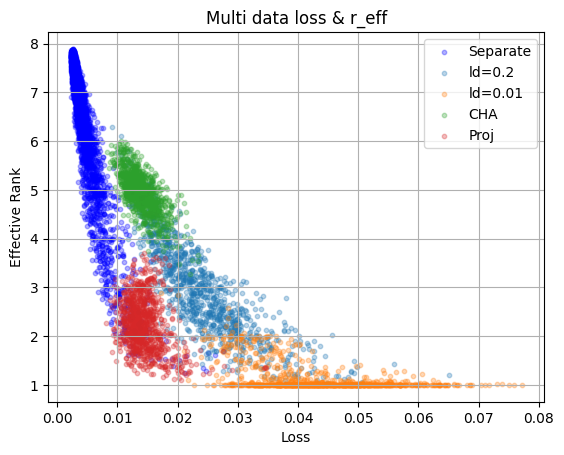

DPC START
centers:  [ 6511  8090  9850 10353 11900]
[0.28067905 2.32608938 3.82016683 1.34842134 1.39733219] 0
Info of top 10 delta: (idx, rho, delta, X)
9986 14 0.5008730888367267 [5.89084435 1.00000381]
9846 7 0.6449864185580574 [6.57308054 1.0006057 ]
9379 28 0.688876390461702 [4.51071358 1.00000238]
9433 0 0.853117999416151 [8.         1.00035071]
9604 5 0.9893322232734862 [3.14824224 1.99885917]
8090 8 1.0113060996813663 [2.32608938 2.87717843]
10353 17 1.2860150894562656 [1.34842134 5.02319431]
11900 12 2.3250924494708447 [1.39733219 2.1220181 ]
9850 29 6.480009265095513 [3.82016683 1.00160134]
6511 874 10.358953042720794 [0.28067905 7.65087891]
pred_l: [0 1 2 3 4]
d_c: 0.0372571210563641
Type 0:  sep
Center:  [0.28067905 7.65087891]
predict:  7838
accuracy:  7834 0.97925
Type 1:  0.2
Center:  [2.32608938 2.87717843]
predict:  372
accuracy:  352 0.352
Type 2:  0.01
Center:  [3.82016683 1.00160134]
predict:  1406
accuracy:  995 0.995
Type 3:  CHA
Center:  [1.34842134 5.02319431]
p

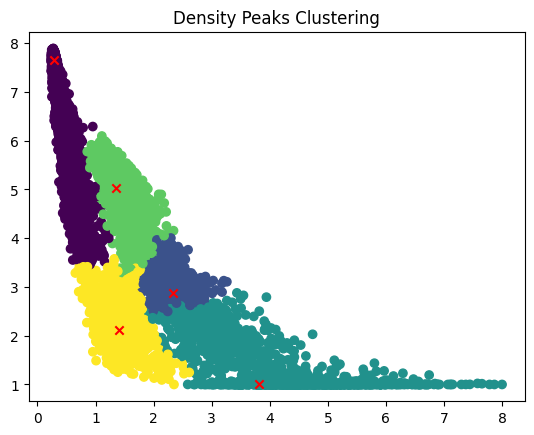

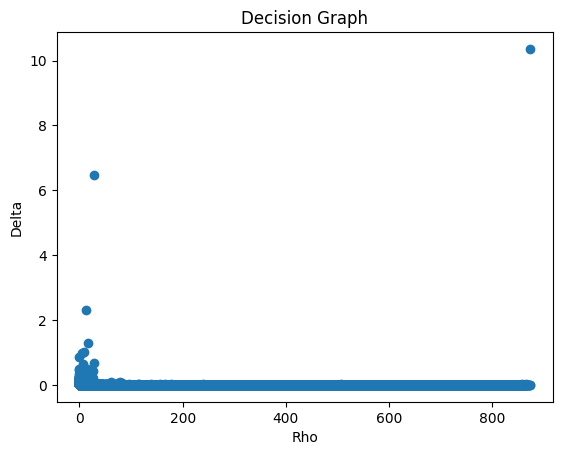

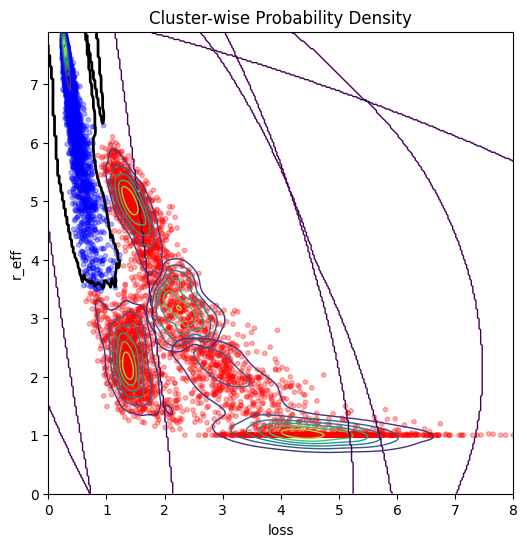

ADDITIONAL TEST START
Type:  lambda=0.2
Type:  lambda=0.01


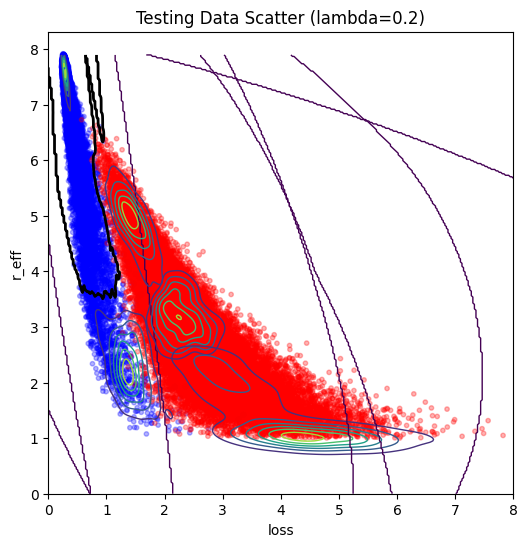

add_sep 38942 0.97355
add_ent 39991 0.999775
f1_score:  0.9864852883434029


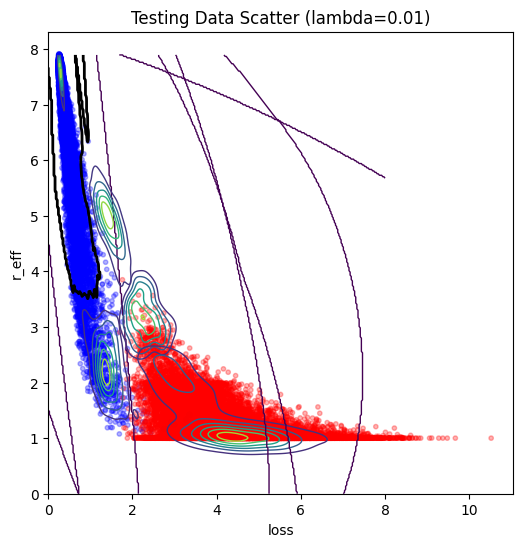

add_sep 38942 0.97355
add_ent 40000 1.0
f1_score:  0.986597755314028


In [9]:
"""Train the model"""
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import pandas as pd
import torch
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt #07180925

from torch.utils.data import Dataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import f1_score

# from loss import l1_loss,l2_loss

class MyDataset(Dataset):
    def __init__(self, nam, set, cons): #09110958
        self.name = nam
        self.set = set
        self.cons = cons
        self.size = len(set)

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        states = self.set[idx]
        rank = self.cons[idx]
        states = np.expand_dims(states, 0)
        states = torch.from_numpy(states).float()
        rank = torch.tensor(rank, dtype=torch.float32)  #09191509
        sample = {'states': states, 'rank': rank}  #09191509
        return sample


def train(model, optimizer, device, train_loader, epoch):
    for mod in model:
        mod.train()
    encoder = model[0]
    decoder = model[1]
    Rank = [] #10042300
    Loss_tr = [] #10042300
    R_EFF = np.array([])
    for batch_idx, data in enumerate(train_loader):
        mix_separable_states = data['states'].to(device)
        state_rank = data['rank'].to(device) #10042300
        Rank = Rank + state_rank.tolist() #10042300
        mix_separable_states_r = mix_separable_states[:, :, :, :, 0] #(1024, 1, 8, 8, 2)
        mix_separable_states_i = mix_separable_states[:, :, :, :, 1]
        mix_state = mix_separable_states_r + 1j * mix_separable_states_i
        r_eff = eff_rank(mix_state)
        R_EFF = np.concatenate((R_EFF, r_eff), axis=-1)
        
        for opt in optimizer:
            opt.zero_grad()
        [latent_var1_r, latent_var1_i, idx_r, idx_i] = encoder(mix_separable_states_r, mix_separable_states_i)
        [fake_mix_states_r, fake_mix_states_i] = decoder(latent_var1_r, latent_var1_i, idx_r, idx_i)

        losscon = l1_loss([mix_separable_states_r, mix_separable_states_i], [fake_mix_states_r, fake_mix_states_i])
        Loss = losscon
        Loss.backward(retain_graph=True)
        
        optimizer[0].step()
        optimizer[1].step()

        if batch_idx % 50 == 0:
            print('Train Epoch: {:3} [{:6}/{:6} ({:3.0f}%)]\tLoss: {:.6f}'.format(
                epoch,
                batch_idx * len(data['states']),
                len(train_loader.dataset),
                100. * batch_idx / len(train_loader),
                Loss.item())
            )

        #10042333
        loss_train = l1_loss([mix_separable_states_r, mix_separable_states_i], [fake_mix_states_r, fake_mix_states_i], test=True)
        Loss_tr = Loss_tr + loss_train.cpu().tolist()

    print('min sep loss:', min(Loss_tr))
    print('max sep loss:', max(Loss_tr))
    return Loss.item(), np.array(Loss_tr), Rank, R_EFF #10042333
    

def test(model, testloader, device):
    for mod in model:
        mod.eval()
    correct = 0.
    total = 0.
    encoder = model[0]
    decoder = model[1]
    # dis = model[2]

    with torch.no_grad():
        Loss = []
        Rank = [] #09191517
        sigma = [] #10171436
        R_EFF = np.array([])
        # time_s = 0
        flag = 0
        for data in testloader:
            # import time
            # time_start = time.time()
            mix_separable_states = data['states'].to(device)
            state_rank = data['rank'].to(device) #10042300
            Rank = Rank + state_rank.tolist() #10042300
            mix_separable_states_r = mix_separable_states[:, :, :, :, 0]
            mix_separable_states_i = mix_separable_states[:, :, :, :, 1]
            
            mix_state = mix_separable_states_r + 1j * mix_separable_states_i  #11091642
            r_eff = eff_rank(mix_state) #[0,1,...,7]
            R_EFF = np.concatenate((R_EFF, r_eff), axis=-1)
            
            [latent_var1_r, latent_var1_i, idx_r, idx_i] = encoder(mix_separable_states_r, mix_separable_states_i)
            [fake_mix_states_r, fake_mix_states_i] = decoder(latent_var1_r, latent_var1_i, idx_r, idx_i)
            
            loss_enc = l1_loss([mix_separable_states_r, mix_separable_states_i], [fake_mix_states_r, fake_mix_states_i], test=True).cpu()
            Loss.append(loss_enc)
            
    return Loss, Rank, R_EFF

def multi_add_test(types, paths, final_model, device, scaling):
    print('ADDITIONAL TEST START')
    X_add_list = []
    sep_size = []
    ent_size = []
    for num in range(len(types)):
        print('Type: ', types[num])
        #Data Preparation
        add_s_test_path = paths['add_s_test'][num] 
        if add_s_test_path is not None:
            add_test_data_s = np.load(add_s_test_path)

            sep_size.append(len(add_test_data_s))
            add_test_set_s = MyDataset(nam='add_test_separable', set=add_test_data_s, cons = np.zeros(len(add_test_data_s)))
            add_test_loader_s = torch.utils.data.DataLoader(add_test_set_s, batch_size=batch_size_v, shuffle=True)
            # Prediction 
            add_loss_s, _, add_r_eff_s = test(final_model, add_test_loader_s, device)
            add_Loss_s = []
            for i in range(len(add_loss_s)):
                add_Loss_s.append(add_loss_s[i].numpy())
            add_loss_s = np.reshape(np.array(add_Loss_s), [len(add_test_data_s)])
        else:
            sep_size.append(0)
            add_loss_s = np.array([])
            add_r_eff_s = np.array([])
            
        add_e_test_path = paths['add_e_test'][num]
        if add_e_test_path is not None:
            add_test_data_e = np.load(add_e_test_path)
                
            ent_size.append(len(add_test_data_e))
            add_test_set_e = MyDataset(nam='add_test_entangled', set=add_test_data_e, cons = np.zeros(len(add_test_data_e)))
            add_test_loader_e = torch.utils.data.DataLoader(add_test_set_e, batch_size=batch_size_v, shuffle=True)
            add_loss_e, _, add_r_eff_e = test(final_model, add_test_loader_e, device)
            add_Loss_e = []
            for i in range(len(add_loss_e)):
                add_Loss_e.append(add_loss_e[i].numpy())
            add_loss_e = np.reshape(np.array(add_Loss_e), [len(add_test_data_e)])
        else:
            ent_size.append(0)
            add_loss_e = np.array([])
            add_r_eff_e = np.array([])

        # #Plot the distribution
        # plt.scatter(add_loss_e, add_r_eff_e, s=10, c='red', alpha=0.6, label="Add Entangle")
        # plt.scatter(add_loss_s, add_r_eff_s, s=10, c='blue', alpha=0.3, label="Add Separate")
        # plt.xlabel("Loss")
        # plt.ylabel("Effective Rank")
        # plt.title(types[num] + " Loss & r_eff relation")
        # plt.grid(True)
        # plt.legend()
        # plt.show()

        loss_add = np.concatenate((add_loss_s, add_loss_e), 0)
        loss_add = loss_add * scaling
        r_eff_add = np.concatenate((add_r_eff_s, add_r_eff_e), 0)
        X_add = np.column_stack([loss_add, r_eff_add])
        X_add_list.append(X_add)
        
    sizes = {'sep_size': sep_size, 'ent_size': ent_size}
    return X_add_list, sizes

def multi_test(types, paths, final_model, device):
    print('MULTI TEST START')
    X_multi_list = []
    multi_sizes = []
    for num in range(len(types)):
        print('Type: ', types[num])
        #Data Preparation
        test_path = paths[num]
        test_data = np.load(test_path)
        multi_sizes.append(len(test_data))
        test_set = MyDataset(nam='test_set_multi', set=test_data, cons = np.zeros(len(test_data)))
        test_loader_multi = torch.utils.data.DataLoader(test_set, batch_size=batch_size_v, shuffle=False)

        loss_multi, _, r_eff_multi = test(final_model, test_loader_multi, device)
        Loss_multi = []
        for i in range(len(loss_multi)):
            Loss_multi.append(loss_multi[i].numpy())
        loss_multi = np.reshape(np.array(Loss_multi), [len(test_data)])
        loss_multi = torch.from_numpy(loss_multi)
        
        X_multi = [loss_multi, r_eff_multi]
        X_multi_list.append(X_multi)

    return X_multi_list, multi_sizes
        
if __name__ == '__main__':
    # generate data
    mix_n = 40
    train_size, s_test_size, e_test_size = TRAIN_CONFIG['train_size'], TRAIN_CONFIG['s_test_size'], TRAIN_CONFIG['e_test_size']
    # Generate_separable_state(name='sep_train_set', size=train_size, sub_dim=2, space_number=4,
    #                          mix_number=mix_n).generate()
    # print('train sep done!!!')
    # Generate_separable_state(name='sep_test_set', size=s_test_size, sub_dim=2, space_number=4,
    #                          mix_number=mix_n).generate()
    # print('test sep done!!!')
    # Generate_entangled_state(name='ent_test_set', size=e_test_size, sub_dim=2, space_number=4).generate_project_data()
    # print('test ent done!!!')
    
    train_data = np.load(TRAIN_CONFIG['train_set_path'])
    test_data_s = np.load(TRAIN_CONFIG['s_test_set_path'])[:s_test_size]
    test_data_e = np.load(TRAIN_CONFIG['e_test_set_path'])
    
    nothing_tr = np.zeros(train_size) #09110958
    nothing_s_te = np.zeros(s_test_size) #09110958
    nothing_e_te = np.zeros(e_test_size) #12032307

    #10042300
    rank_tr = []
    for _ in range(int(train_size / mix_n)):
        rank_tr += range(1, mix_n+1)
    
    #09191504
    rank_te = []
    for _ in range(int(s_test_size / mix_n)):
        rank_te += range(1, mix_n+1)

    #10171435
    sigma_sep = np.linspace(0.8, 0.999, 200)
    sigma_ent = np.linspace(0.6, 0.799, 200)
    
    train_set = MyDataset(nam='train', set=train_data, cons = rank_tr)
    test_set_s = MyDataset(nam='test_separable', set=test_data_s, cons = nothing_s_te)
    test_set_e = MyDataset(nam='test_entangled', set=test_data_e, cons = nothing_e_te)

    batch_size_t = TRAIN_CONFIG['train_config']['batch_size']
    batch_size_v = TRAIN_CONFIG['validation_data_config']['batch_size']
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size_t, shuffle=True)
    test_loader_s = torch.utils.data.DataLoader(test_set_s, batch_size=batch_size_v, shuffle=False)
    test_loader_e = torch.utils.data.DataLoader(test_set_e, batch_size=batch_size_v, shuffle=True)
    
    file_writer = open(TRAIN_CONFIG['result_path'], 'a')
    if TRAIN_CONFIG['is_train']:
        AUC = []
        EER = []
        EFF_ACC = []
        Loss_train = []
        THs = []
        device = TRAIN_CONFIG['train_config']['device']
        c1, k1, c2, k2, c3, k3, d1, d2 = MODEL_CONFIG['c1'], MODEL_CONFIG['k1'], MODEL_CONFIG['c2'], MODEL_CONFIG['k2'], MODEL_CONFIG['c3'], \
                                         MODEL_CONFIG['k3'], MODEL_CONFIG['d1'], MODEL_CONFIG['d2']
        model_1 = Encoder_r(k1=k1, c1=c1, k2=k2, c2=c2, k3=k3, c3=c3, d1=d1, d2=d2).to(device)
        optimizer_1 = torch.optim.RMSprop(model_1.parameters(), lr=0.0001, momentum=0.9)
        model_2 = Generator(k1=k1, c1=c1, k2=k2, c2=c2, k3=k3, c3=c3, d1=d1, d2=d2).to(device)
        optimizer_2 = torch.optim.RMSprop(model_2.parameters(), lr=0.0001, momentum=0.9)
        mkdir('./Model_%d_%d_%d/' % (k1, k2, k3) + 'Channel_%d_%d_%d' % (c1, c2, c3))
        for epoch in range(TRAIN_CONFIG['train_config']['epoch']):
            loss, loss_tr, rank_tr, r_eff_tr = train([model_1, model_2], [optimizer_1, optimizer_2], device,
                               train_loader,
                               epoch) #08062334

            if epoch%50 == 0 or epoch == 99:
                loss_s, _, r_eff_s = test([model_1, model_2], test_loader_s, device)
                Loss_s = []
                for i in range(len(loss_s)):
                    Loss_s.append(loss_s[i].numpy())
                loss_s = np.reshape(np.array(Loss_s), [len(test_data_s)])
                loss_s = torch.from_numpy(loss_s)
                label_s = torch.zeros(len(loss_s))
                
                loss_e, _, r_eff_e = test([model_1, model_2], test_loader_e, device)
                Loss_e = []
                for i in range(len(loss_e)):
                    Loss_e.append(loss_e[i].numpy())
                loss_e = np.reshape(np.array(Loss_e), [len(test_data_e)])
                loss_e = torch.from_numpy(loss_e)
                label_e = torch.ones(len(loss_e))
                rank_e = nothing_e_te.tolist()
                
                score = torch.cat((loss_s, loss_e), 0)
                la = torch.cat((label_s, label_e), 0)
                # rank = rank_s + rank_e
                # sigma = sigma_s + sigma_e
    
                mkdir('./roc/')
                roc_auc, eer, key_thresh = roc(la, score, epoch, saveto='./roc/')
                print('key threshold:', key_thresh)

                #plot
                plt.scatter(loss_e, r_eff_e, s=10, c='red', alpha=0.6, label="Entangle")
                plt.scatter(loss_s, r_eff_s, s=10, c='blue', alpha=0.3, label="Separate")
                plt.xlabel("Loss")
                plt.ylabel("Effective Rank")
                plt.title("Loss & r_eff relation")
                plt.grid(True)
                plt.legend()
                plt.show()

        #         loss_cluster = score.detach().cpu().numpy()
        #         r_eff_cluster = np.concatenate((r_eff_s, r_eff_e), 0)
        #         scaling = dim / max(loss_cluster)
        #         loss_cluster = loss_cluster * scaling
                
        #         #sort (20260128)
        #         pairs = list(zip(loss_cluster, r_eff_cluster))
        #         pairs_sorted = sorted(pairs, key=lambda x: x[0])
        #         loss_cluster, r_eff_cluster = zip(*pairs_sorted)
                
        #         X = np.column_stack([loss_cluster, r_eff_cluster])
        #         model = DensityPeaksClustering()
        #         label_dpc = model.fit(X)
                
        #         #evaluate
        #         print('d_c:', model.dc)
        #         print('amount of 0:', label_dpc.count(0))
        #         sep_actual = label_dpc[:len(loss_s)].count(0)
        #         print('sep', sep_actual, sep_actual/len(loss_s))
        #         print('amount of 1:', label_dpc.count(1))
        #         ent_actual = label_dpc[len(loss_s):].count(1)
        #         print('ent', ent_actual, ent_actual/len(loss_e))

        #         #plot
        #         model.dpc_plot(X)

        #         #Density Contour
        #         model.density_contour(X)

        #     if epoch == 99:         
        #         #multi_add_test
        #         types = ['CHA', 'Proj', 'PPT+CHA', 'Werner']
        #         paths = {
        #             'add_s_test':[
        #                 '/data0817projection164/sep_test_set.npy',
        #                 '/data0817projection164/sep_test_set.npy',
        #                 '/ppt1203testdata/sep_1305test_set.npy',
        #                 '/1017rho400test/sep_test_set.npy'
        #             ],
        #             'add_e_test':[
        #                 '/0904cha40000ent/0904ent40000.npy',
        #                 '/data0817projection164/ent_test_set.npy',
        #                 '/ppt1203testdata/ent_8748test_set.npy',
        #                 '/1017rho400test/ent_test_set.npy'
        #             ],
        #         }
        #         X_add_list, sizes = multi_add_test(types, paths, [model_1, model_2], device, scaling)

        # for i, X_add in enumerate(X_add_list):
        #     add_sep_size = sizes['sep_size'][i]
        #     add_ent_size = sizes['ent_size'][i]
        #     labels_add, density = model.predict_clusters_by_density(X_add)
        #     actual_add_label = np.concatenate((np.zeros(add_sep_size), np.ones(add_ent_size)), 0)
        #     model.density_contour(X, X_add, actual_add_label, types[i])
            
        #     add_sep_actual = labels_add[:add_sep_size].count(0)
        #     print('add_sep', add_sep_actual, add_sep_actual/add_sep_size)
        #     add_ent_actual = labels_add[add_sep_size:].count(1)
        #     print('add_ent', add_ent_actual, add_ent_actual/add_ent_size)

        #     print('f1_score: ', f1_score(actual_add_label, labels_add, pos_label=0))

        #     # #animation
        #     # if epoch == 0 or epoch == 99:
        #     #     model.dpc_animation(X)

        #03141542
        torch.save(model_1, './Model_%d_%d_%d/' % (k1, k2, k3) + 'Channel_%d_%d_%d/' % (c1, c2, c3) + 'model1')
        torch.save(model_2, './Model_%d_%d_%d/' % (k1, k2, k3) + 'Channel_%d_%d_%d/' % (c1, c2, c3) + 'model2')
        
        # #08062111
        # Performance = np.array([AUC, EER])
        # Pd_data = pd.DataFrame(Performance.T, columns=["AUC", "EER"])
        # file_writer.write('results of %d-%d kernel' % (k1, k2) + str(c1) + '-' + str(c2) + ' ent with projection\n') #(U-Net*1 & ) (Data0702)
        # file_writer.write('AUC:' + str(np.mean(AUC[-10:])) + '\n')
        # file_writer.write('EER:' + str(np.mean(EER[-10:])) + '\n')
        # file_writer.write('_________________________\n')
        # file_writer.flush()
        torch.cuda.empty_cache()

    else:
        device = TRAIN_CONFIG['validation_data_config']['device']
        model_1 = torch.load('/kaggle/input/models/nameunknown404/20260314model/pytorch/default/2/Encoder', weights_only=False).to(device)
        model_2 = torch.load('/kaggle/input/models/nameunknown404/20260314model/pytorch/default/2/Decoder', weights_only=False).to(device)

        print('sep test')
        loss_s, _, r_eff_s = test([model_1, model_2], test_loader_s, device)
        Loss_s = []
        for i in range(len(loss_s)):
            Loss_s.append(loss_s[i].numpy())
        loss_s = np.concatenate(Loss_s)
        loss_s = torch.from_numpy(loss_s)
        label_s = torch.zeros(len(loss_s))

        loss_cluster, r_eff_cluster = loss_s, r_eff_s
        #multi_ent_test
        ld_types = [0.2, 0.01]
        ld_paths = [
            f'/kaggle/input/{qb}qb-calibration/lambda_cal_data/lambda_ent_cal_1k_{ld}.npy'
            for ld in ld_types
        ]
        other_types = ['CHA', 'Proj']
        other_paths = [
            f'/kaggle/input/{qb}qb-calibration/rand_ent_cal_1k.npy',
            f'/kaggle/input/{qb}qb-calibration/proj_ent_cal_1k.npy'
        ]
        total_types = ld_types + other_types
        total_paths = ld_paths + other_paths
        
        X_multi_list, multi_sizes = multi_test(total_types, total_paths, [model_1, model_2], device)
        multi_sizes.insert(0, s_test_size)
        intervals = np.array(np.cumsum(np.array(multi_sizes)))
        
        plt.figure()
        plt.scatter(loss_s, r_eff_s, s=10, c='blue', alpha=0.3, label="Separate")
        for idx, t in enumerate(total_types):
            #plot
            if idx < len(ld_types):
                plt.scatter(X_multi_list[idx][0], X_multi_list[idx][1], s=10, alpha=0.3, label=f'ld={t}')
            else:
                plt.scatter(X_multi_list[idx][0], X_multi_list[idx][1], s=10, alpha=0.3, label=t)
            #features preparation
            loss_cluster = torch.cat((loss_cluster, X_multi_list[idx][0]), 0)
            r_eff_cluster = np.concatenate((r_eff_cluster, X_multi_list[idx][1]), 0)

        plt.xlabel("Loss")
        plt.ylabel("Effective Rank")
        plt.title("Multi data loss & r_eff")
        plt.grid(True)
        plt.legend()
        plt.show()

        loss_cluster = loss_cluster.detach().cpu().numpy()
        scaling = (2 ** qb) / max(loss_cluster)
        loss_cluster = loss_cluster * scaling
        total_types = ['sep'] + total_types

        # print('ent test')
        # loss_e, _, r_eff_e = test([model_1, model_2], test_loader_e, device)
        # Loss_e = []
        # for i in range(len(loss_e)):
        #     Loss_e.append(loss_e[i].numpy())
        # loss_e = np.reshape(np.array(Loss_e), [len(test_data_e)])
        # loss_e = torch.from_numpy(loss_e)
        # label_e = torch.ones(len(loss_e))
        # rank_e = nothing_e_te.tolist()
        
        # score = torch.cat((loss_s, loss_e), 0)
        # la = torch.cat((label_s, label_e), 0)

        # mkdir('./roc/')
        # roc_auc, eer, key_thresh = roc(la, score, epoch, saveto='./roc/')
        # print('key threshold:', key_thresh)
        
        # #plot
        # plt.scatter(loss_e, r_eff_e, s=10, c='red', alpha=0.6, label="Entangle")
        # plt.scatter(loss_s, r_eff_s, s=10, c='blue', alpha=0.3, label="Separate")
        # plt.xlabel("Loss")
        # plt.ylabel("Effective Rank")
        # plt.title("Loss & r_eff relation")
        # plt.grid(True)
        # plt.legend()
        # plt.show()

        # loss_cluster = score.detach().cpu().numpy()
        # r_eff_cluster = np.concatenate((r_eff_s, r_eff_e), 0)
        # scaling = dim / max(loss_cluster)
        # loss_cluster = loss_cluster * scaling
        
        # #sort (20260128)
        # pairs = list(zip(loss_cluster, r_eff_cluster))
        # pairs_sorted = sorted(pairs, key=lambda x: x[0])
        # loss_cluster, r_eff_cluster = zip(*pairs_sorted)
        
        X = np.column_stack([loss_cluster, r_eff_cluster])

        model = DensityPeaksClustering()
        print('DPC START')
        label_dpc = model.fit(X)

        # #GMM
        # print('GMM')
        # gmm_labels = gmm_cluster(X)
        # gmm_kdes = gmm_density_contour(X, gmm_labels, gmm_kdes=None)
        
        #evaluate
        pred_l = np.searchsorted(intervals, model.centers_, side='right')
        print('pred_l:', pred_l)
        intervals = np.insert(intervals, 0, 0)
        
        print('d_c:', model.dc)
        for l in np.unique(label_dpc):
            print(f'Type {l}: ', total_types[l])
            if l not in pred_l:
                print('Center: NO')
                continue
            true_l = np.argmax(pred_l == l)
            print('Center: ', X[model.centers_[true_l]])
            
            l_actual = label_dpc[intervals[l]:intervals[l+1]].count(true_l)
            print('predict: ', label_dpc.count(true_l))
            print('accuracy: ', l_actual, l_actual/multi_sizes[l])            

        #plot
        halo = False
        model.dpc_plot(X, halo=halo)

        #Density Contour
        if halo:
            X, label_core = X[model.core_mask_], model.labels_[model.core_mask_]
            core_sep_num = len(X) - np.sum(label_core)
            print(len(X), core_sep_num, np.sum(label_core))
            
            model.density_contour(X, label_core=label_core)
        else:
            label_core = None
            model.density_contour(X, label_core=label_core)
        
        # model.density_contour_3d(X)       
       
        #multi_add_test
        types = ['lambda=0.2', 'lambda=0.01'] #, 'PPT', 'Werner'
        size = 10 if qb == 5 else 40
        paths = {
            'add_s_test':[
                # f'/kaggle/input/{qb}qb-train-and-test/rand_sep_test_{size}k.npy',
                # f'/kaggle/input/{qb}qb-train-and-test/rand_sep_test_{size}k.npy',
                f'/kaggle/input/{qb}qb-train-and-test/rand_sep_test_{size}k.npy',
                f'/kaggle/input/{qb}qb-train-and-test/rand_sep_test_{size}k.npy'
            ],
            'add_e_test':[
                # f'/kaggle/input/{qb}qb-train-and-test/rand_ent_test_{size}k.npy',
                # f'/kaggle/input/{qb}qb-train-and-test/proj_ent_test_{size}k.npy',
                f'/kaggle/input/{qb}qb-train-and-test/lambda_ent_test_{size}k_0.2.npy',
                f'/kaggle/input/{qb}qb-train-and-test/lambda_ent_test_{size}k_0.01.npy'
            ]
        }     
        X_add_list, sizes = multi_add_test(types, paths, [model_1, model_2], device, scaling)
        
        for i, X_add in enumerate(X_add_list):
            add_sep_size = sizes['sep_size'][i]
            add_ent_size = sizes['ent_size'][i]
            actual_add_label = np.concatenate((np.zeros(add_sep_size), np.ones(add_ent_size)), 0)
            
            #original
            labels_add, density = model.predict_clusters_by_density(X_add)
            model.density_contour(X, X_add, actual_add_label, types[i], label_core=label_core)

            real_labels_add = np.where(labels_add == 0, labels_add, 1).tolist()
            add_sep_actual = real_labels_add[:add_sep_size].count(0)
            add_ent_actual = real_labels_add[add_sep_size:].count(1)
            if add_sep_size == 0:
                print('add_sep', add_sep_actual)
            else:
                print('add_sep', add_sep_actual, add_sep_actual/add_sep_size)
            if add_ent_size == 0:
                print('add_ent', add_ent_actual)
            else:
                print('add_ent', add_ent_actual, add_ent_actual/add_ent_size)
            print('f1_score: ', f1_score(actual_add_label, real_labels_add, pos_label=0))

            # #GMM
            # gmm_add_label = np.concatenate((np.zeros(add_sep_size), np.ones(add_ent_size)), 0)
            # add_pack = [X_add, gmm_add_label, types[i]]
            # gmm_density_contour(X, gmm_labels, gmm_kdes=gmm_kdes, add_pack=add_pack)

            # gmm_labels_test, _ = gmm_predict_clusters(X_add, gmm_kdes)
            # add_sep_actual = gmm_labels_test[:add_sep_size].count(0)
            # print('add_sep', add_sep_actual, add_sep_actual/add_sep_size)
            # add_ent_actual = gmm_labels_test[add_sep_size:].count(1)
            # print('add_ent', add_ent_actual, add_ent_actual/add_ent_size)
            # print('f1_score: ', f1_score(gmm_add_label, gmm_labels_test, pos_label=0))
